In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

import sys
sys.path.append('../src/')

import FSC as controller

import os
import time as measure_time

import pickle
import matplotlib.pyplot as plt

In [3]:
from dataclasses import dataclass
from typing import List, Tuple

@dataclass
class Agent:
    pos: int               # 0 .. N_SITES-1
    orient: int            # +1 for right, -1 for left

def p_concentration(position: int, N: int) -> float:
    # if N <= 1:
    #     return 1.0
    # return position / (N - 1)

    # put a gaussian source around 3/4 of the track
    center = (N - 1) / 2
    sigma = 1
    p = np.exp(-0.5 * ((position - center) / sigma) ** 2)
    return p

def step(agent: Agent, action: str, N: int) -> Tuple[str, Agent]:    
    if action == "runbackwards":
        # flip orientation
        agent.orient = -agent.orient
    elif action == "runforward":
        pass
    else:
        raise ValueError(f"Unknown action: {action}")

    # Apply action dynamics
    new_pos = agent.pos + agent.orient
    # Reflect at boundaries
    if new_pos < 0:
        new_pos = 0
    elif new_pos >= N:
        new_pos = N - 1
    agent.pos = new_pos

    pc = p_concentration(agent.pos, N)
    obs = '1' if np.random.rand() < pc else '0'

    return obs, agent

In [5]:
# Parameters
N_SITES = 26
NUM_SEQUENCES = 100
MAX_STEPS_PER_SEQ = 100
OUTPUT_FILENAME = '../data/ChemoKinetic/output_sequences_automata.txt'
STATES_FILENAME = '../data/ChemoKinetic/agent_states_automata.txt'

np.random.seed(9)
with open(OUTPUT_FILENAME, 'w') as f_seq, open(STATES_FILENAME, 'w') as f_states:
    for _ in range(NUM_SEQUENCES):
        # Random initial conditions (start centered, start in '+')
        start_pos = np.random.randint(0, N_SITES)
        start_orient = np.random.choice([+1, -1])
        agent = Agent(pos=start_pos, orient=start_orient)
        
        seq: List[Tuple[str, str]] = []
        states: List[Tuple[int, int]] = [(agent.pos, agent.orient)]  # record initial state

        for t in range(MAX_STEPS_PER_SEQ):
            if t == 0:
                if np.random.rand() < 0.5:
                        action = 'runforward'
                else:
                    action = 'runbackwards'
            elif t == 1:
                if obs == '1':
                    action = 'runforward'
                else:
                    if np.random.rand() < 0.5:
                        action = 'runforward'
                    else:
                        action = 'runbackwards'
            else:
                if seq[t-1][1] == '1' and seq[t-2][1] == '1':
                    if np.random.rand() < 0.5:
                        action = 'runforward'
                    else:
                        action = 'runbackwards'
                elif seq[t-1][1] == '1' and seq[t-2][1] == '0':
                    action = 'runforward'
                elif seq[t-1][1] == '0' and seq[t-2][1] == '1':
                    action = 'runbackwards'
                elif seq[t-1][1] == '0' and seq[t-2][1] == '0':
                    if np.random.rand() < 0.5:
                        action = 'runforward'
                    else:
                        action = 'runbackwards'

            obs, agent = step(agent, action, N_SITES)
            seq.append((action, obs))
            states.append((agent.pos, agent.orient))

            # # Optional stopping criterion: stop if at boundary for stability
            # if agent.pos in (0, N_SITES - 1):
            #     break

        # Write sequences as space-separated pairs: action+obs (e.g., "run1", "tumble0")
        line_seq = ' '.join([f"{a}{o}" for a, o in seq])
        f_seq.write(line_seq + '\n')

        # Write states as space-separated "pos,orient" pairs (initial + subsequent)
        line_states = ' '.join([f"{pos},{orient}" for pos, orient in states])
        f_states.write(line_states + '\n')

In [6]:
# Load generated sequences
action_sequences = []
observation_sequences = []

with open(OUTPUT_FILENAME, 'r') as f:
    for line in f:
        pairs = line.strip().split()
        actions = []
        observations = []
        for p in pairs:
            actions.append("F" if p.startswith('runforward') else "B")
            observations.append(p[-1])
        action_sequences.append(np.array(actions))
        observation_sequences.append(np.array(observations))

trajectories_data = [
    { 'actions': a, 'observations': y}
    for a, y in zip(action_sequences, observation_sequences)
]

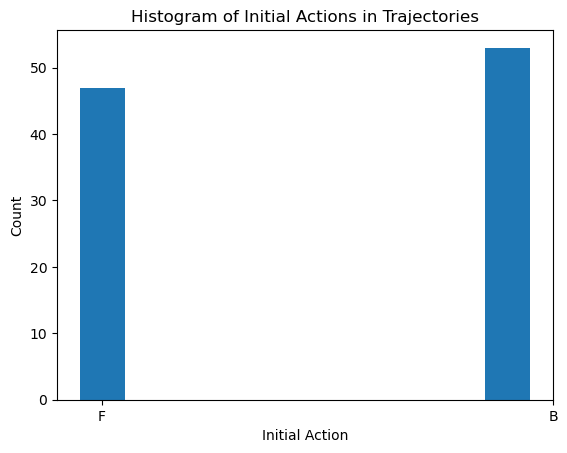

In [7]:
initial_actions = [trj['actions'][0] for trj in trajectories_data]

plt.hist(initial_actions, align = 'left', rwidth = 1)
plt.xlabel("Initial Action")
plt.ylabel("Count")
plt.title("Histogram of Initial Actions in Trajectories")
plt.show()

In [8]:
# Load agent states (positions, orientations, and optional memory states)
agent_states_trajectories = []

with open(STATES_FILENAME, 'r') as f:
    for line in f:
        pairs = line.strip().split()
        positions = []
        orientations = []
        mem_states = []
        for p in pairs:
            parts = p.split(',')
            pos_str, orient_val = parts

            positions.append(int(pos_str))
            orientations.append(orient_val)

        agent_states_trajectories.append({
            'positions': np.array(positions),
            'orientations': np.array(orientations, dtype=object)
        })

In [9]:
# Spaces
ActSpace = np.array(['F', 'B'])
ObsSpace = np.array(['0', '1'])

A = len(ActSpace)
Y = len(ObsSpace)

In [11]:
M = 4
MemSpace = np.array(["00", "01", "10", "11"])  

# Indices
idx_F = np.where(ActSpace == 'F')[0][0]
idx_B = np.where(ActSpace == 'B')[0][0]
idx_obs0 = np.where(ObsSpace == '0')[0][0]
idx_obs1 = np.where(ObsSpace == '1')[0][0]
idx_00 = np.where(MemSpace == '00')[0][0]
idx_01 = np.where(MemSpace == '01')[0][0]
idx_10 = np.where(MemSpace == '10')[0][0]
idx_11 = np.where(MemSpace == '11')[0][0]

psi_real = np.ones(M)
psi_real[1:] = -np.inf

# zeta: action logits per memory state
zeta_real = np.ones((A, M)) * -np.inf
zeta_real[idx_F, idx_01] = 0.0
zeta_real[idx_B, idx_10] = 0.0
zeta_real[:, idx_00] = 0.0
zeta_real[:, idx_11] = 0.0

# theta: observation-conditioned memory transitions (logits)
# Shape (Y, A, M, M)
theta_real = np.ones((Y, A, M, M)) * -np.inf
theta_real[idx_obs1, :, idx_00, idx_01] = 0.0
theta_real[idx_obs0, :, idx_00, idx_00] = 0.0

theta_real[idx_obs1, :, idx_01, idx_11] = 0.0
theta_real[idx_obs0, :, idx_01, idx_10] = 0.0

theta_real[idx_obs1, :, idx_10, idx_01] = 0.0
theta_real[idx_obs0, :, idx_10, idx_00] = 0.0

theta_real[idx_obs1, :, idx_11, idx_11] = 0.0
theta_real[idx_obs0, :, idx_11, idx_10] = 0.0

FSC_exact = controller.FSC(M=M, A=A, Y=Y,
                           mode='generation',
                           policy_model='softmax',
                           policy_params={'theta': theta_real.copy(), 'zeta': zeta_real.copy()},
                           psi=psi_real.copy(),
                           ActSpace=ActSpace, MemSpace=MemSpace,
                           ObsSpace=ObsSpace)

# Evaluate loss on generated trajectories
loss = FSC_exact.compute_loss(trajectories_data)
print('Negative log-likelihood:', loss)

Negative log-likelihood: 54.79328462326368


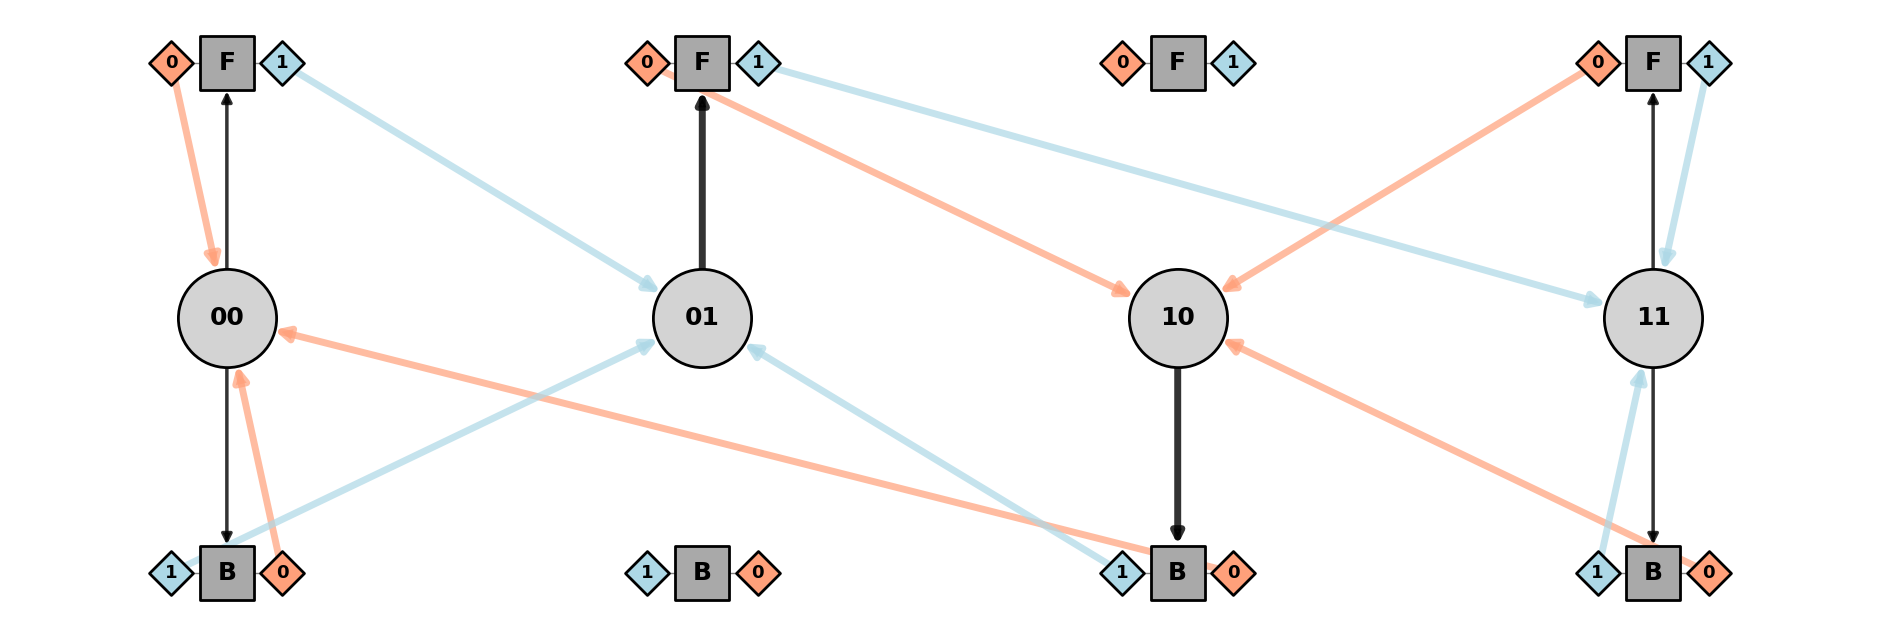

In [12]:
# Optional: visualize the exact FSC
FSC_exact.set_mode('generation')
observation_node_colors = ["lightsalmon", "lightblue"]
ax = FSC_exact.plot_FSC(memory_ordering=[0,1,2,3],
                        observation_node_colors=observation_node_colors,
                        th_action_probs=1e-3, th_mem_transitions=1e-3)
plt.show()

## M = 2

In [ ]:
NEpochs_MAPSO = 100
M = 2
MemSpace = np.array(["M" + str(num) for num in range(M)])

FSC_M2 = controller.FSC(M = M, A = A, Y = Y,
                          mode = "inference",
                          policy_model = "softmax",
                          policy_params = {"theta": None, "zeta": None},
                          psi = None,
                          ActSpace = ActSpace, MemSpace = MemSpace,
                          ObsSpace = ObsSpace)

FSC_M2.set_inference_params(use_gradient = False, use_MAPSO = True,
                              trainable_parameters = "all",
                              n_particles_MAPSO = 50, NEpochs_MAPSO = NEpochs_MAPSO,
                              dynamic_topology_MAPSO = True, num_neighbors_init_MAPSO = 50, num_neighbors_final_MAPSO = 50,
                              num_neighbors_mid_MAPSO = 2,
                              init_particles_MAPSO = {"distribution": "normal", "mean": 0, "std": 1}, # 1
                              init_velocities_MAPSO = {"distribution": "uniform", "vmin": -0.01, "vmax": +0.01},
                              print_params = False)
        
_ = FSC_M2.fit(trajectories_data, verbose_MAPSO=False,
                    verbose_epochs_MAPSO=True)

Initial best value: 68.59467792732755
Iteration 1/100, best value: 68.59467792732755
Iteration 2/100, best value: 65.3716855002428
Iteration 3/100, best value: 65.30157424672063
Iteration 4/100, best value: 64.464438629912
Iteration 5/100, best value: 64.39397809195785
Iteration 6/100, best value: 64.06922870792457
Iteration 7/100, best value: 64.0691737673088
Iteration 8/100, best value: 64.0691737673088
Iteration 9/100, best value: 64.0691737673088
Iteration 10/100, best value: 63.98918655861627
Iteration 11/100, best value: 63.98918655861627
Iteration 12/100, best value: 63.83756694095779
Iteration 13/100, best value: 63.464642300444275
Iteration 14/100, best value: 63.21047695657495
Iteration 15/100, best value: 63.21047695657495
Iteration 16/100, best value: 63.21047695657495
Iteration 17/100, best value: 63.21047695657495
Iteration 18/100, best value: 62.88078251096915
Iteration 19/100, best value: 62.84049400977262
Iteration 20/100, best value: 62.84049400977262
Iteration 21/100

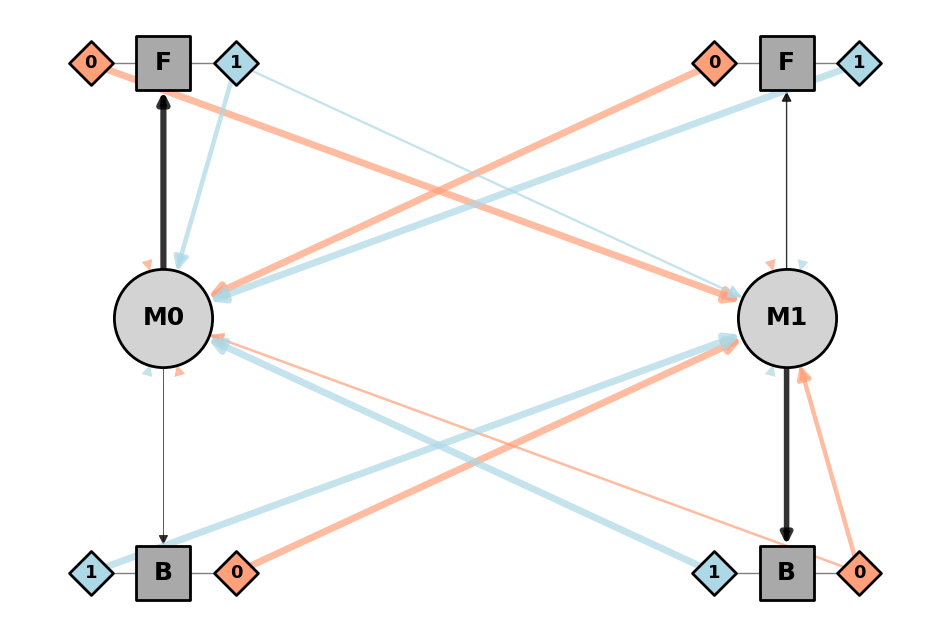

In [430]:
FSC_M2.set_mode("generation")
observation_node_colors = ["lightsalmon", "lightblue"]
ax = FSC_M2.plot_FSC(observation_node_colors=observation_node_colors,
                     th_action_probs=1e-6, th_mem_transitions=1e-13)
plt.show()

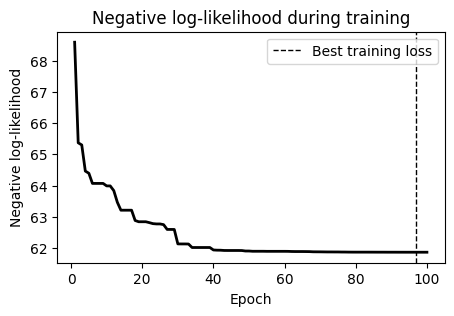

In [432]:
FSC_M2.plot_losses()

## M = 3

In [ ]:
NEpochs_MAPSO = 100
M = 3
MemSpace = np.array(["M" + str(num) for num in range(M)])

FSC_M3 = controller.FSC(M = M, A = A, Y = Y,
                          mode = "inference",
                          policy_model = "softmax",
                          policy_params = {"theta": None, "zeta": None},
                          psi = None,
                          ActSpace = ActSpace, MemSpace = MemSpace,
                          ObsSpace = ObsSpace)

FSC_M3.set_inference_params(use_gradient = False, use_MAPSO = True,
                              trainable_parameters = "all",
                              n_particles_MAPSO = 50, NEpochs_MAPSO = NEpochs_MAPSO,
                              dynamic_topology_MAPSO = True, num_neighbors_init_MAPSO = 50, num_neighbors_final_MAPSO = 50,
                              num_neighbors_mid_MAPSO = 2,
                              init_particles_MAPSO = {"distribution": "normal", "mean": 0, "std": 1}, # 1
                              init_velocities_MAPSO = {"distribution": "uniform", "vmin": -0.01, "vmax": +0.01},
                              print_params = False)
        
_ = FSC_M3.fit(trajectories_data, verbose_MAPSO=False,
                    verbose_epochs_MAPSO=True)

Initial best value: 68.03735456714888
Iteration 1/100, best value: 68.03735456714888
Iteration 2/100, best value: 67.41177393120158
Iteration 3/100, best value: 66.82219461860123
Iteration 4/100, best value: 64.6843328560724
Iteration 5/100, best value: 64.6843328560724
Iteration 6/100, best value: 64.55560282645683
Iteration 7/100, best value: 64.55560282645683
Iteration 8/100, best value: 64.40580379435737
Iteration 9/100, best value: 64.40325447324905
Iteration 10/100, best value: 64.40325447324905
Iteration 11/100, best value: 64.40325447324905
Iteration 12/100, best value: 64.40325447324905
Iteration 13/100, best value: 64.34860370639328
Iteration 14/100, best value: 64.20943530103746
Iteration 15/100, best value: 63.97295625049287
Iteration 16/100, best value: 63.97295625049287
Iteration 17/100, best value: 63.97295625049287
Iteration 18/100, best value: 61.188992946645506
Iteration 19/100, best value: 61.188992946645506
Iteration 20/100, best value: 60.76165864016849
Iteration 2

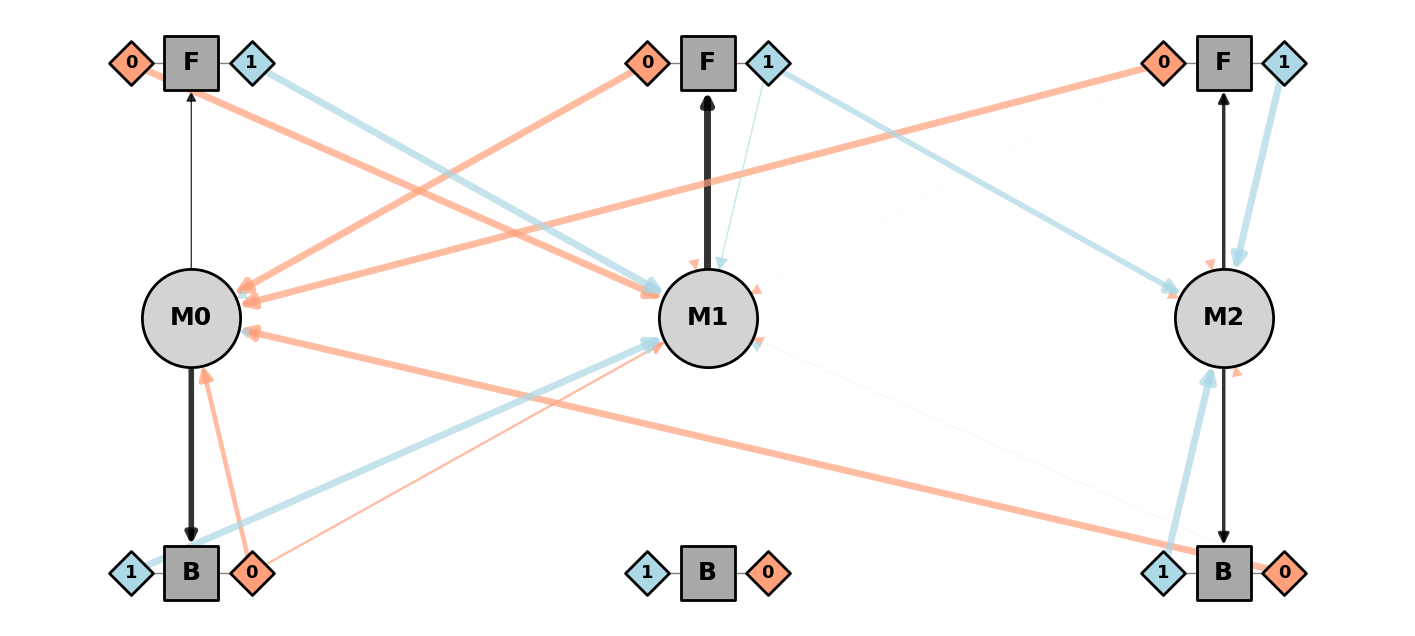

In [434]:
FSC_M3.set_mode("generation")
ax = FSC_M3.plot_FSC(observation_node_colors=observation_node_colors,
                     th_action_probs=1e-6, th_mem_transitions=1e-13)
plt.show()

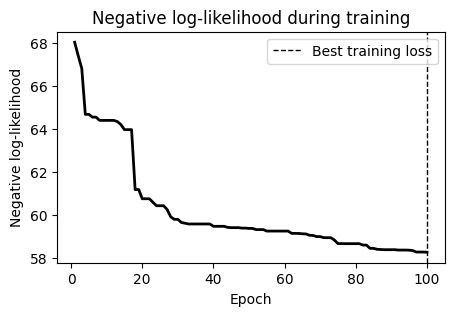

In [436]:
FSC_M3.plot_losses()

## M = 4

In [19]:
NEpochs_MAPSO = 1000
M = 4
MemSpace = np.array(["M" + str(num) for num in range(M)])

FSC_M4 = controller.FSC(M = M, A = A, Y = Y,
                          mode = "inference",
                          policy_model = "softmax",
                          policy_params = {"theta": None, "zeta": None},
                          psi = psi_real.copy(),
                          ActSpace = ActSpace, MemSpace = MemSpace,
                          ObsSpace = ObsSpace)

FSC_M4.set_inference_params(use_gradient = False, use_MAPSO = True,
                              trainable_parameters = ["zeta", "theta"],
                              n_particles_MAPSO = 50, NEpochs_MAPSO = NEpochs_MAPSO,
                              dynamic_topology_MAPSO = True, num_neighbors_init_MAPSO = 50, num_neighbors_final_MAPSO = 50,
                              num_neighbors_mid_MAPSO = 2,
                              init_particles_MAPSO = {"distribution": "normal", "mean": 0, "std": 1},
                              init_velocities_MAPSO = {"distribution": "uniform", "vmin": -0.01, "vmax": +0.01},
                              print_params = False)
        
_ = FSC_M4.fit(trajectories_data, verbose_MAPSO=False,
                    verbose_epochs_MAPSO=True)

Initial best value: 66.98460730756196
Iteration 1/1000, best value: 66.98460730756196
Iteration 2/1000, best value: 66.17505187811747
Iteration 3/1000, best value: 64.55710055985244
Iteration 4/1000, best value: 63.59709388183706
Iteration 5/1000, best value: 63.29520500180207
Iteration 6/1000, best value: 63.29520500180207
Iteration 7/1000, best value: 63.05741993167834
Iteration 8/1000, best value: 63.05741993167834
Iteration 9/1000, best value: 62.882821611236565
Iteration 10/1000, best value: 62.86253705134345
Iteration 11/1000, best value: 61.988168271301326
Iteration 12/1000, best value: 61.96473539740541
Iteration 13/1000, best value: 61.96473539740541
Iteration 14/1000, best value: 61.771784216117496
Iteration 15/1000, best value: 61.41216429543333
Iteration 16/1000, best value: 60.96796459684574
Iteration 17/1000, best value: 60.92756663394039
Iteration 18/1000, best value: 60.896052275757974
Iteration 19/1000, best value: 60.896052275757974
Iteration 20/1000, best value: 60.8

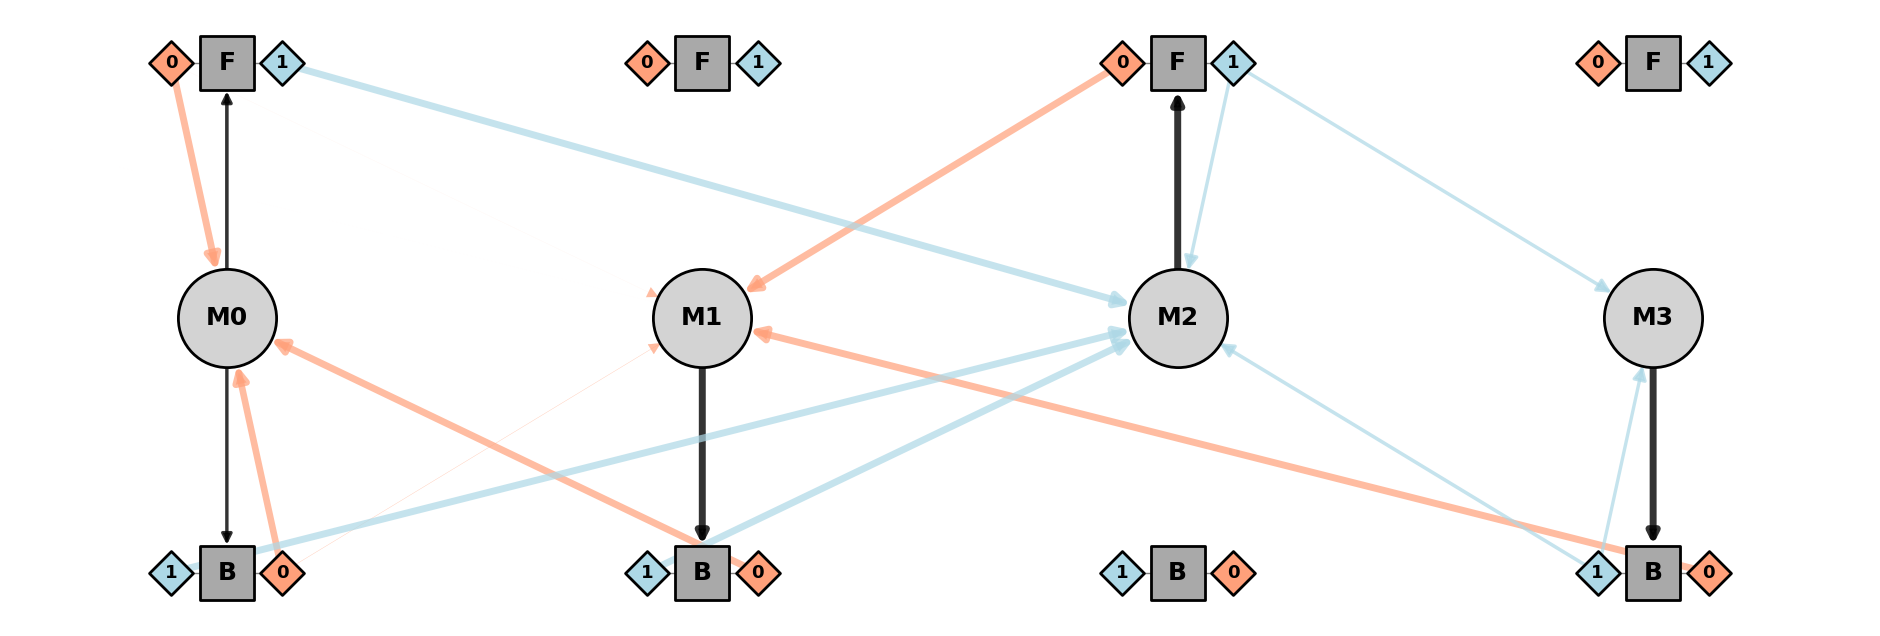

In [20]:
FSC_M4.set_mode("generation")
ax = FSC_M4.plot_FSC(observation_node_colors=observation_node_colors,
                     th_action_probs=1e-6, th_mem_transitions=1e-6)
plt.show()

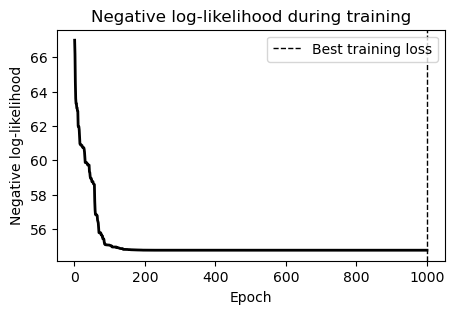

In [22]:
FSC_M4.plot_losses()